# Sales Performance Dashboard — Superstore
**Goal:** Analyze the Superstore sales CSV using Pandas — total revenue, top products, and bar chart visualizations.

**Dataset:** `SuperstoreDataset.csv` (Order/Ship dates, Customer, Category, Sub-Category, Product Name, Sales, Profit, Quantity, Discount)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("SuperstoreDataset.csv", encoding="latin1")

print(f"Shape: {df.shape}")
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 1. Data Cleaning & Overview

In [2]:
# Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

df.info()

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str         

## 2. Total Revenue

In [3]:
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_rows = len(df)
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit:  ${total_profit:,.2f}")
print(f"Unique Orders: {total_orders:,}")
print(f"Line Items: {total_rows:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Overall Profit Margin: {(total_profit/total_revenue)*100:.2f}%")
print(f"Date Range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")

Total Revenue: $2,297,200.86
Total Profit:  $286,397.02
Unique Orders: 5,009
Line Items: 9,994
Average Order Value: $458.61
Overall Profit Margin: 12.47%
Date Range: 2014-01-03 to 2017-12-30


## 3. Top Products

In [4]:
top_products_revenue = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
print("Top 10 Products by Revenue:")
top_products_revenue.head(10)

Top 10 Products by Revenue:


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [5]:
top_products_qty = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False)
print("Top 10 Products by Units Sold:")
top_products_qty.head(10)

Top 10 Products by Units Sold:


Product Name
Staples                                                       215
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
KI Adjustable-Height Table                                     74
Avery Non-Stick Binders                                        71
Storex Dura Pro Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Situations Contoured Folding Chairs, 4/Set                     64
Staple-based wall hangings                                     62
Name: Quantity, dtype: int64

In [6]:
top_subcategories = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
print("Revenue by Sub-Category:")
top_subcategories

Revenue by Sub-Category:


Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

## 4. Revenue by Category & Region

In [7]:
revenue_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
revenue_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print("Revenue by Category:\n", revenue_by_category)
print("\nRevenue by Region:\n", revenue_by_region)

Revenue by Category:
 Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Revenue by Region:
 Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


## 5. Revenue Trend Over Time

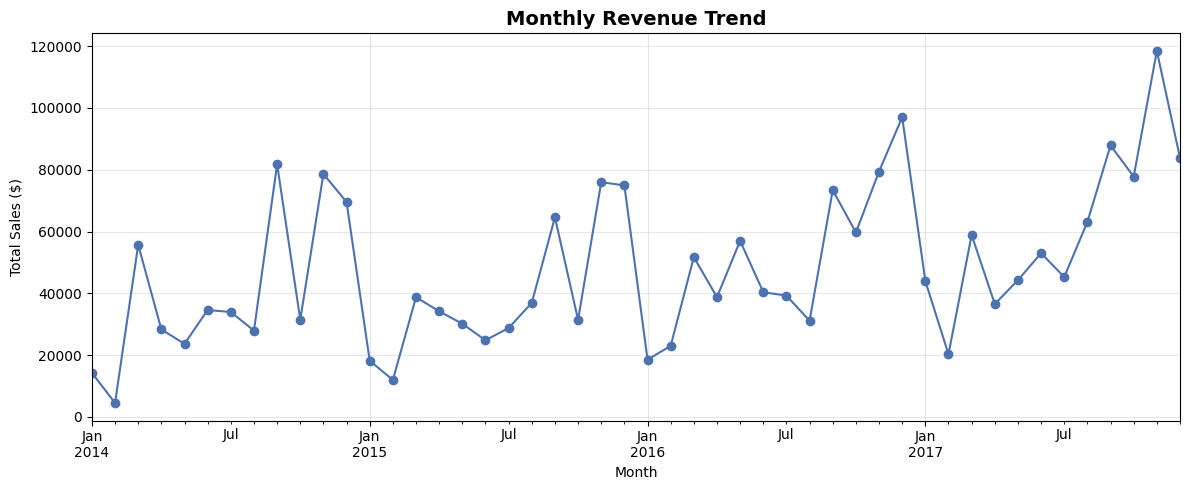

In [8]:
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()

fig, ax = plt.subplots(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', color='#4C72B0', ax=ax)
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150)
plt.show()

## 6. Bar Charts

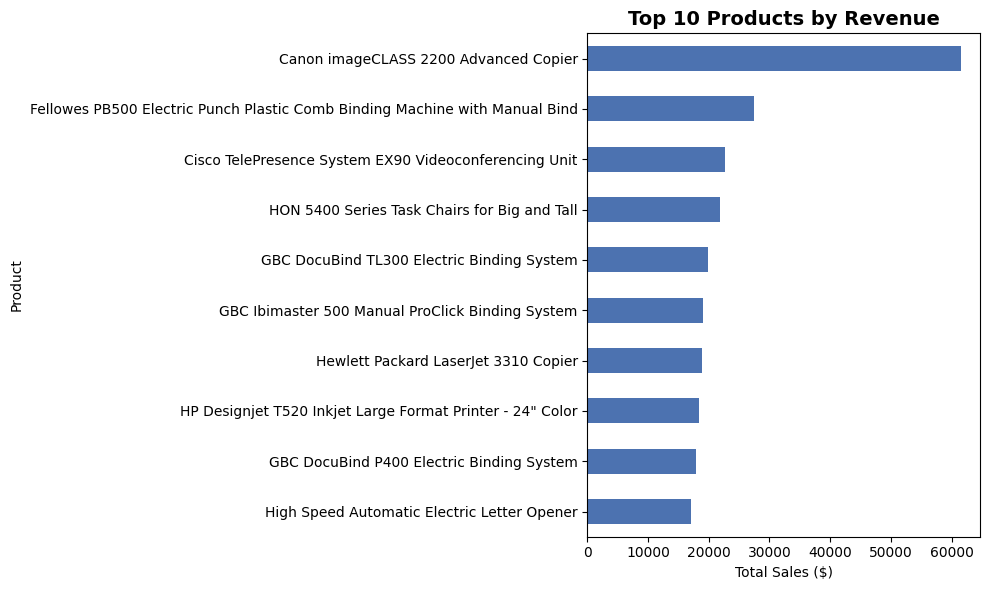

In [9]:
fig, ax = plt.subplots(figsize=(10,6))
top_products_revenue.head(10).sort_values().plot(kind='barh', color='#4C72B0', ax=ax)
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Product')
plt.tight_layout()
plt.savefig('top_products_revenue.png', dpi=150)
plt.show()

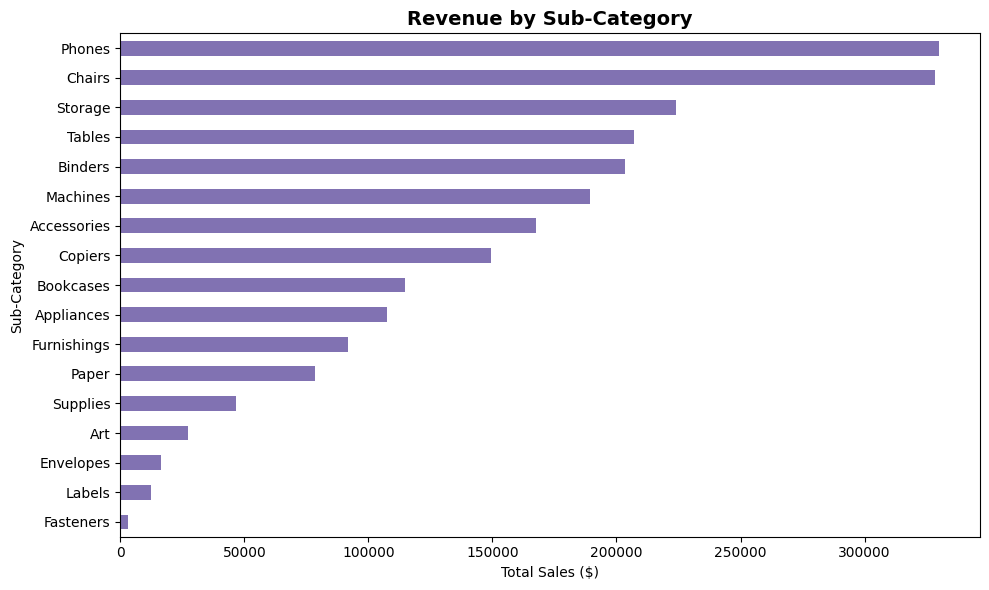

In [10]:
fig, ax = plt.subplots(figsize=(10,6))
top_subcategories.sort_values().plot(kind='barh', color='#8172B2', ax=ax)
ax.set_title('Revenue by Sub-Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('revenue_by_subcategory.png', dpi=150)
plt.show()

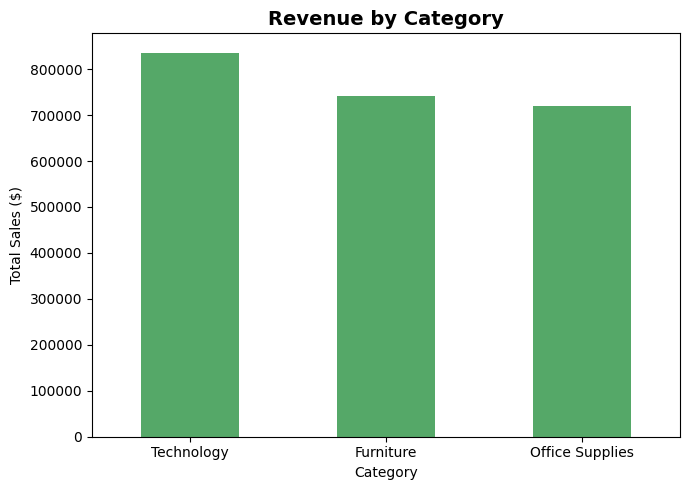

In [11]:
fig, ax = plt.subplots(figsize=(7,5))
revenue_by_category.plot(kind='bar', color='#55A868', ax=ax)
ax.set_title('Revenue by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=150)
plt.show()

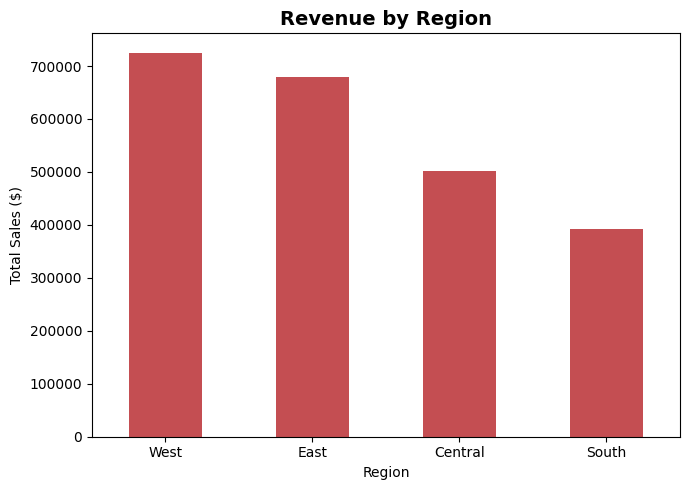

In [12]:
fig, ax = plt.subplots(figsize=(7,5))
revenue_by_region.plot(kind='bar', color='#C44E52', ax=ax)
ax.set_title('Revenue by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('revenue_by_region.png', dpi=150)
plt.show()

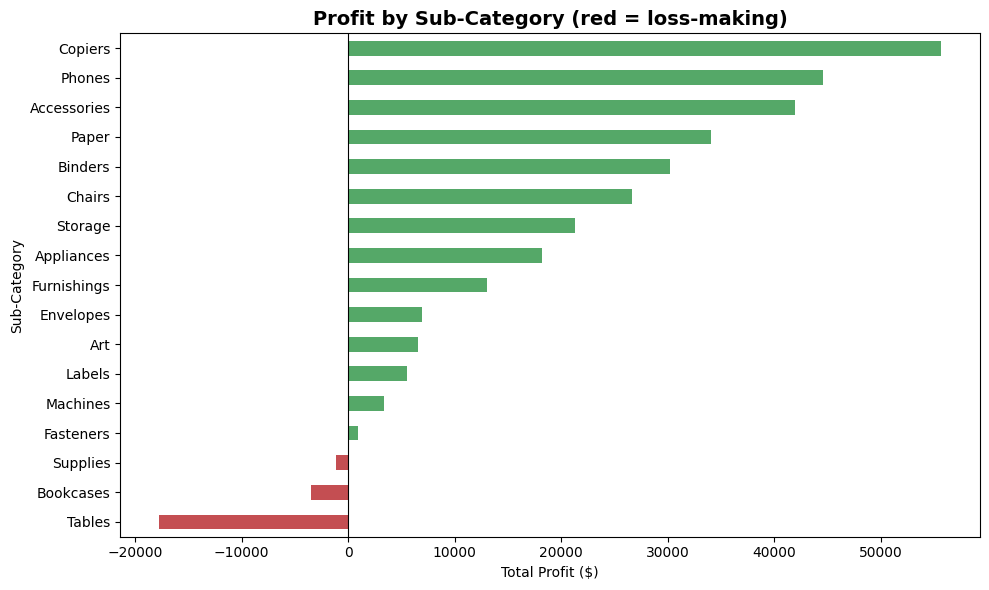

In [13]:
profit_by_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10,6))
colors = ['#C44E52' if v < 0 else '#55A868' for v in profit_by_subcat.values]
profit_by_subcat.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Profit by Sub-Category (red = loss-making)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('profit_by_subcategory.png', dpi=150)
plt.show()

## 7. Key Insights

*(Fill this in after reading the actual output above — numbers below are placeholders to guide structure, not final answers.)*

- **Top revenue product:** see the Top 10 Products chart
- **Best-performing category/region:** see Section 4
- **Loss-making sub-categories:** check which bars in the profit chart go negative — often driven by high discount rates
- **Trend:** note whether revenue is seasonal or growing month over month from the trend chart